In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn import linear_model
from sklearn.datasets import load_diabetes, make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
from sklearn import metrics

from tqdm.notebook import tqdm

random_state=809

In [2]:
def plot_lasso_Ridge(alphas, regs_1, regs_2, ols, X, title=None, model_1_title='Lasso', model_2_title='Ridge'):
    reg_1_coefs = [model.coef_ for model in regs_1] 
    reg_2_coefs = [model.coef_ for model in regs_2] 
    OLS_Coefs = ols.coef_ 
    
    fig, (ax, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
    
    ax.plot(alphas, reg_2_coefs)
    ax.set_xscale('log')
    ax.set_xlim(ax.get_xlim()[::-1])
    ax.set_xlabel('Lambda (Penalty Term)', fontsize=14)
    ax.set_ylabel('Weights', fontsize=14)
    ax.set_title(f'{model_2_title} Coefficients', fontsize=16)
    
    ax1.plot(alphas, reg_1_coefs)
    ax1.set_xscale('log')
    ax1.set_xlim(ax1.get_xlim()[::-1])
    ax1.set_xlabel('Lambda (Penalty Term)', fontsize=14)
    ax1.set_title(f'{model_1_title} Coefficients', fontsize=16)
    
    plt.axis('tight')
    plt.legend(X.columns, loc='best')
    if title: plt.suptitle(title, fontsize=20)
    plt.show()
    
    last_coefs_df = pd.DataFrame()
    last_coefs_df['OLS'] = OLS_Coefs
    last_coefs_df['Lasso'] = reg_1_coefs[-1]
    last_coefs_df['Ridge'] = reg_2_coefs[-1]
    last_coefs_df['Variable'] = [f'Variable {i}' for i in range(len(reg_2_coefs[-1]))]
    last_coefs_df.set_index('Variable', inplace=True)
    return last_coefs_df

# Load a Dataset

In [3]:
X_not_std, y = load_diabetes(return_X_y=True)
X_not_std = pd.DataFrame(X_not_std)
X_not_std.columns = ['Variable '+str(i) for i in range(len(X_not_std.columns))]
X_not_std

,Variable 0,Variable 1,Variable 2,Variable 3,Variable 4,Variable 5,Variable 6,Variable 7,Variable 8,Variable 9
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.017282,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930


# Running the regressions

In [4]:
#Penalty Terms
n_alphas = 2000
alphas = np.logspace(4.5, -5, n_alphas)
alphas = alphas.tolist()

In [5]:
def Run_Model(X, alphas):
    #OLS
    OLS = linear_model.LinearRegression()
    OLS.fit(X, y)

    #LASSO and Ridge
    Ridge_models = []
    LASSO_models = []
    
    for a in tqdm(alphas):
        ridge = linear_model.Ridge(alpha=a)
        ridge.fit(X, y)
        Ridge_models.append(ridge)
    
        lasso = linear_model.Lasso(alpha=a)
        lasso.fit(X, y)
        LASSO_models.append(lasso)
    return OLS, LASSO_models, Ridge_models

# First Regression: Without any standardization:

In [6]:
OLS, LASSO_models, Ridge_models = Run_Model(X_not_std, alphas)

  0%|          | 0/2000 [00:00<?, ?it/s]

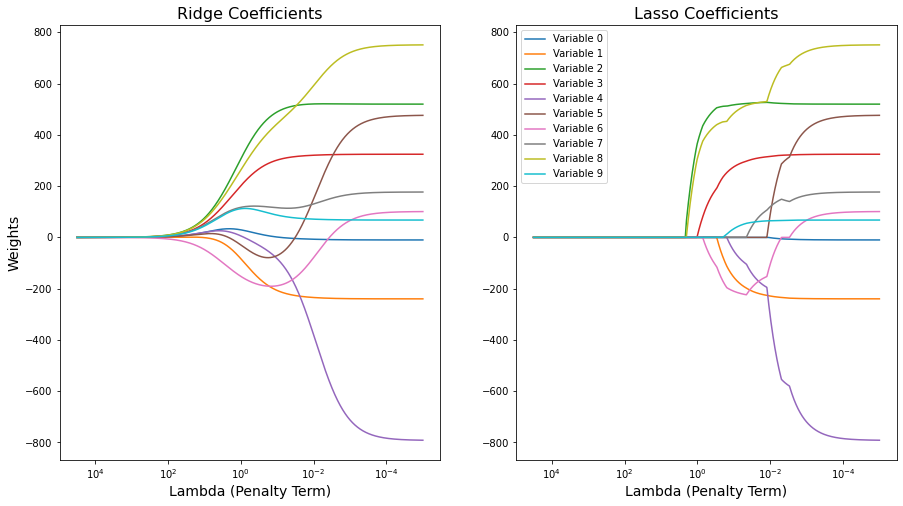

In [7]:
last_coefs_df = plot_lasso_Ridge(alphas, LASSO_models, Ridge_models, OLS, X_not_std)

In [8]:
# Looking at the Coeficients for the OLS and Lasso and ridge with the smallest coefficients
last_coefs_df

,OLS,Lasso,Ridge
Variable,,,
Variable 0,-10.012198,-10.002060,-10.007164
Variable 1,-239.819089,-239.809895,-239.811324
Variable 2,519.839787,519.844004,519.846094
Variable 3,324.390428,324.380817,324.384392
Variable 4,-792.184162,-791.464643,-791.293412
Variable 5,476.745838,476.192279,476.039029
Variable 6,101.044570,100.701379,100.651057
Variable 7,177.064176,176.937998,176.956985
Variable 8,751.279321,751.019861,750.941594


# Second Regression: With Multiplying Variable 3 by 10:

In [9]:
X_not_std2 = X_not_std.copy()
X_not_std2['Variable 3'] = X_not_std['Variable 3']*10
X_not_std2

,Variable 0,Variable 1,Variable 2,Variable 3,Variable 4,Variable 5,Variable 6,Variable 7,Variable 8,Variable 9
0,0.038076,0.050680,0.061696,0.218724,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.263278,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,-0.092204
2,0.085299,0.050680,0.044451,-0.056706,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.366564,0.012191,0.024991,-0.036038,0.034309,0.022692,-0.009362
4,0.005383,-0.044642,-0.036385,0.218724,0.003935,0.015596,0.008142,-0.002592,-0.031991,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.597439,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.676423,0.049341,0.079165,-0.028674,0.034309,-0.018118,0.044485
439,0.041708,0.050680,-0.015906,0.172819,-0.037344,-0.013840,-0.024993,-0.011080,-0.046879,0.015491
440,-0.045472,-0.044642,0.039062,0.012151,0.016318,0.015283,-0.028674,0.026560,0.044528,-0.025930


In [10]:
OLS_var_3, LASSO_models_var_3, Ridge_models_var_3 = Run_Model(X_not_std2, alphas)

  0%|          | 0/2000 [00:00<?, ?it/s]

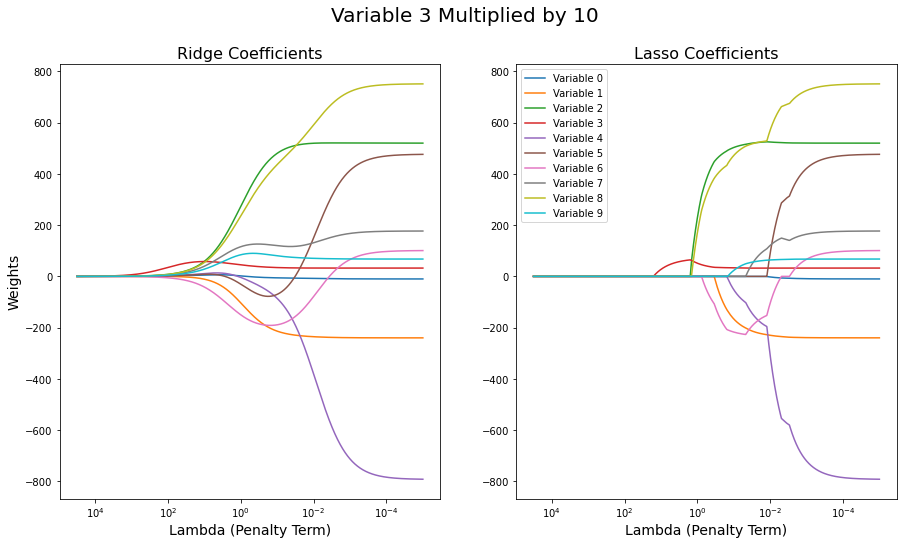

In [11]:
last_coefs_df_var_3 = plot_lasso_Ridge(alphas, LASSO_models_var_3, Ridge_models_var_3, OLS_var_3, X_not_std2,  title = 'Variable 3 Multiplied by 10')

### What Changed?

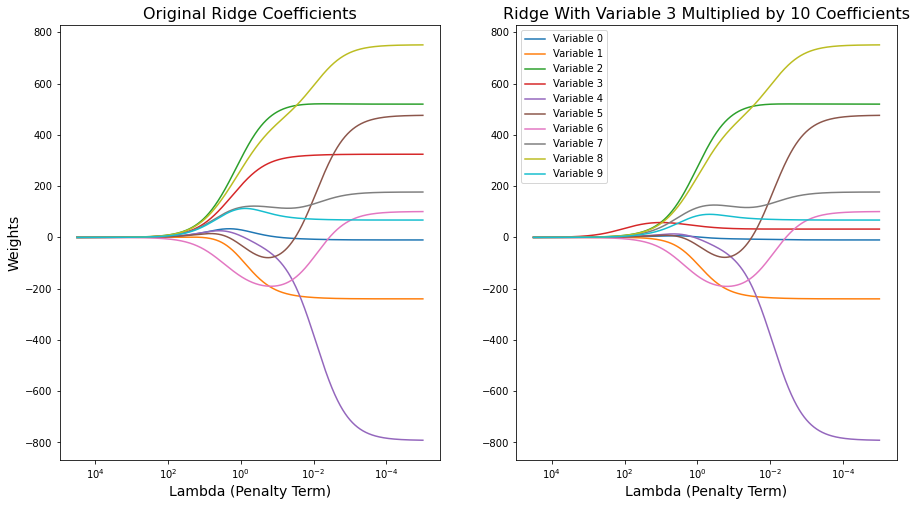

In [12]:
_ = plot_lasso_Ridge(alphas, Ridge_models_var_3, Ridge_models, OLS_var_3, X_not_std2, 
                     model_2_title='Original Ridge', model_1_title='Ridge With Variable 3 Multiplied by 10')

In [13]:
df_compare = last_coefs_df['OLS'].to_frame()
df_compare['OLS Var 3 Multiplied by 10'] = last_coefs_df_var_3['OLS']
df_compare

,OLS,OLS Var 3 Multiplied by 10
Variable,,
Variable 0,-10.012198,-10.012198
Variable 1,-239.819089,-239.819089
Variable 2,519.839787,519.839787
Variable 3,324.390428,32.439043
Variable 4,-792.184162,-792.184162
Variable 5,476.745838,476.745838
Variable 6,101.044570,101.044570
Variable 7,177.064176,177.064176
Variable 8,751.279321,751.279321


# Third Regression: With Standardized Variables

In [14]:
# Rescaling the varaibles
scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_not_std), columns =X_not_std.columns)
X_std.describe()

,Variable 0,Variable 1,Variable 2,Variable 3,Variable 4,Variable 5,Variable 6,Variable 7,Variable 8,Variable 9
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-9.544904e-18,-8.389468e-17,2.411344e-17,2.059690e-17,-5.927888e-17,-5.450642e-17,5.325052e-17,2.717786e-16,2.951385e-18,-2.025152e-17
std,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00,1.001133e+00
min,-2.254290e+00,-9.385367e-01,-1.897929e+00,-2.363066e+00,-2.665411e+00,-2.430626e+00,-2.150883e+00,-1.606102e+00,-2.651046e+00,-2.896390e+00
25%,-7.841722e-01,-9.385367e-01,-7.196249e-01,-7.706577e-01,-7.200196e-01,-6.382488e-01,-7.382960e-01,-8.303008e-01,-6.990157e-01,-6.975491e-01
50%,1.131724e-01,-9.385367e-01,-1.531324e-01,-1.192178e-01,-9.084100e-02,-8.029125e-02,-1.384305e-01,-5.449919e-02,-4.094666e-02,-2.265729e-02
75%,8.005001e-01,1.065488e+00,6.569519e-01,7.493688e-01,5.961931e-01,6.274425e-01,6.162390e-01,7.213025e-01,6.818695e-01,5.869224e-01
max,2.327895e+00,1.065488e+00,3.585718e+00,2.776071e+00,3.235851e+00,4.179278e+00,3.809072e+00,3.894331e+00,2.808758e+00,2.851075e+00


In [15]:
OLS_std, LASSO_models_std, Ridge_models_std = Run_Model(X_std, alphas)

  0%|          | 0/2000 [00:00<?, ?it/s]

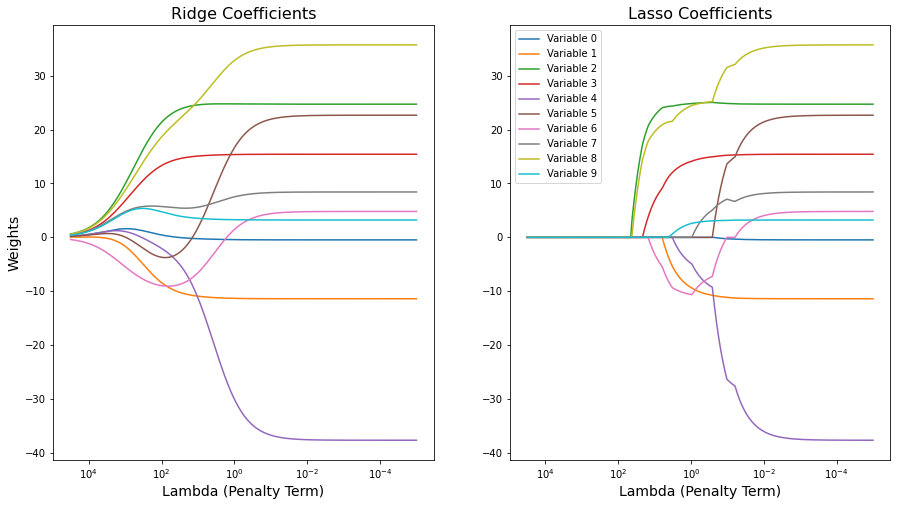

In [16]:
last_coefs_df = plot_lasso_Ridge(alphas, LASSO_models_std, Ridge_models_std, OLS_std, X_std)

# Fourth Regression: With uncorrelated Variables

Remember that if the variables are uncorrelated, we should see 

<font size="5">$$\hat{\beta}_k^{LASSO} =sign(\hat{\beta}_k^{OLS}) [max(0, | \hat{\beta}_k^{OLS}|-\lambda)]$$

### Principal Components Analysis

In [17]:
pca = PCA()
X_pca = pd.DataFrame(pca.fit_transform(X_not_std), columns =X_not_std.columns)
X_pca_std = pd.DataFrame(scaler.fit_transform(X_pca), columns =X_pca.columns)
X_pca_std

,Variable 0,Variable 1,Variable 2,Variable 3,Variable 4,Variable 5,Variable 6,Variable 7,Variable 8,Variable 9
0,0.292719,-1.593664,0.536562,-0.084719,-0.315368,-1.302524,-0.245470,1.150177,-0.647035,-0.529125
1,-1.411540,1.123182,0.025420,-0.480825,-0.176012,-1.304843,0.306366,-0.286096,1.804921,0.471119
2,0.135664,-1.338320,0.673188,-0.809706,-1.430199,-1.433381,-0.631269,1.280449,-0.090620,-0.585657
3,0.024581,0.312911,-1.833095,1.404871,0.314014,0.573601,0.658218,-0.558556,-0.492669,-0.806130
4,-0.377086,0.664673,-0.052140,-0.140687,-0.163865,-1.049258,0.595835,-1.609283,0.158288,-0.117734
...,...,...,...,...,...,...,...,...,...,...
437,0.617898,-0.848028,0.845676,-0.671382,0.251079,-0.617468,0.538470,0.192061,-1.350308,-0.272686
438,0.630433,0.623197,-1.593761,-1.159590,-0.115532,1.253855,-1.602137,0.273997,-1.328331,0.361738
439,-0.102314,-0.986773,0.451735,-1.384522,-0.174116,-0.058336,-0.867506,-0.746630,-0.404628,0.636172
440,0.345389,0.172001,-0.791075,1.654031,0.147035,-0.717331,0.744983,0.119469,-0.454558,-0.492202


  0%|          | 0/2000 [00:00<?, ?it/s]

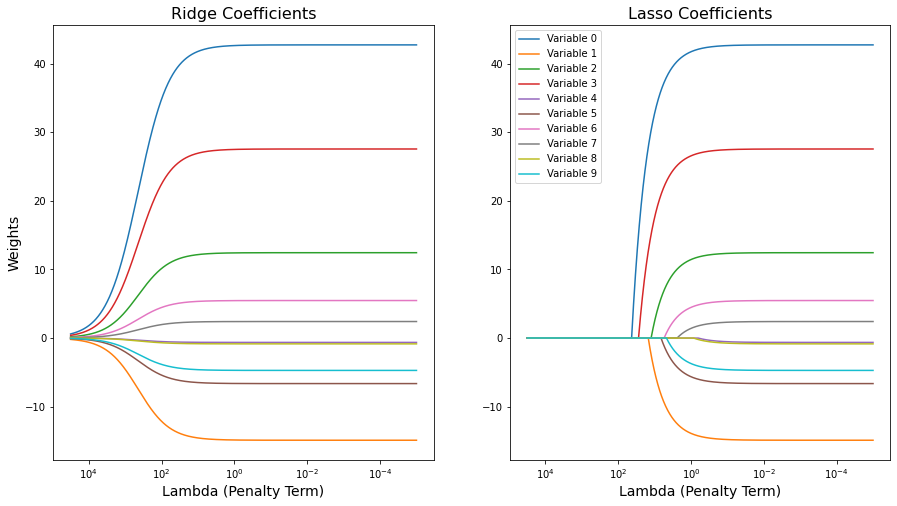

In [18]:
OLS, LASSO_models, Ridge_models = Run_Model(X_pca_std, alphas)
Last_coefs_df = plot_lasso_Ridge(alphas, LASSO_models, Ridge_models, OLS, X_pca_std)

### Taking an Example and applying the formula

In [19]:
iteration_nb = 735
penalty = alphas[iteration_nb]
print(f"The penalty term is {penalty}")

The penalty term is 10.162568869975953


In [20]:
def theoretical_lasso_coef(ols_coef, penalty):
    return np.sign(ols_coef)*np.max([0, np.abs(ols_coef)-penalty])

OLS_coefs = OLS.coef_
theoretical_Lasso_ceofs = [theoretical_lasso_coef(coef, penalty) for coef in OLS_coefs]
Lasso_coefs = LASSO_models[iteration_nb].coef_

coefs_df = pd.DataFrame()
coefs_df['OLS'] = OLS_coefs
coefs_df['Theoretical Lasso Coef'] = theoretical_Lasso_ceofs
coefs_df['LASSO'] = Lasso_coefs
coefs_df['Variable'] = [f'Variable {i}' for i in range(len(Lasso_coefs))]
coefs_df.set_index('Variable', inplace=True)
coefs_df

,OLS,Theoretical Lasso Coef,LASSO
Variable,,,
Variable 0,42.765768,32.603199,32.603199
Variable 1,-14.918522,-4.755953,-4.755953
Variable 2,12.444582,2.282013,2.282013
Variable 3,27.575869,17.413300,17.413300
Variable 4,-0.645272,-0.000000,-0.000000
Variable 5,-6.652626,-0.000000,-0.000000
Variable 6,5.464362,0.000000,0.000000
Variable 7,2.402340,0.000000,0.000000
Variable 8,-0.857938,-0.000000,-0.000000


In [21]:
theoretical_lasso_coefs = [[theoretical_lasso_coef(ols_coef, penalty) for ols_coef in OLS_coefs] for penalty in alphas]

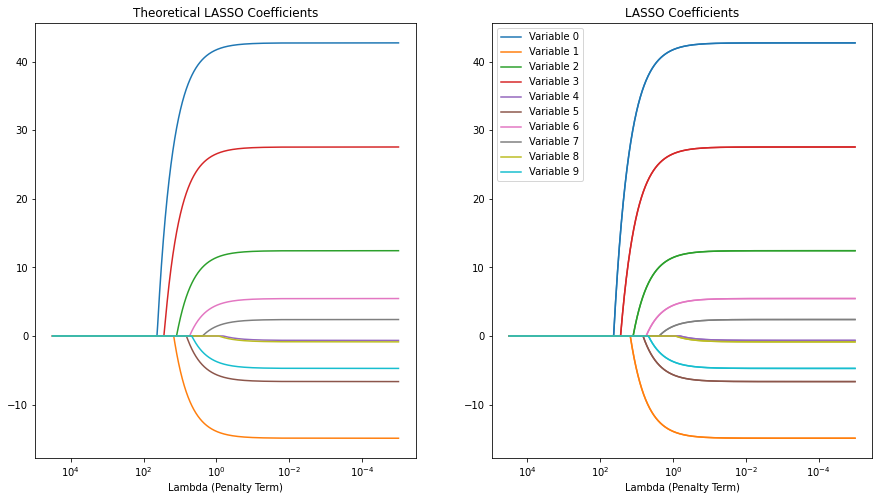

In [22]:
Lasso_coefs = [model.coef_ for model in LASSO_models] 

fig, (ax, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
    
ax.plot(alphas[::-1], theoretical_lasso_coefs[::-1])
ax.set_xscale('log')
ax.set_xlim(ax.get_xlim()[::-1])
ax.set_xlabel('Lambda (Penalty Term)')
ax.set_title('Theoretical LASSO Coefficients')
    
ax1.plot(alphas, Lasso_coefs)
ax1.set_xscale('log')
ax1.set_xlim(ax1.get_xlim()[::-1])
ax1.set_xlabel('Lambda (Penalty Term)')
ax1.set_title('LASSO Coefficients')
    
ax1.plot(alphas, Lasso_coefs)

plt.axis('tight')
plt.legend(X_pca_std.columns, loc='best')
plt.show()

# Iso-RSS Curves

In [23]:
def _plot_MSE(df_MSE, df_MSE_OLS=pd.DataFrame()):
    fig, ax = plt.subplots(figsize=(10, 8))
    plot = ax.scatter(df_MSE['beta_1'], df_MSE['beta_2'], alpha = .8, c = df_MSE['MSE'], cmap = 'coolwarm')
    ax.set_xlabel(r'Coefficient on First Variable ($\beta_1$)', fontsize=14)
    ax.set_ylabel(r'Coefficient on Second Variable ($\beta_2$)', fontsize=14)
    ax.set_title('Mean Square Error', fontsize=18)
    plt.colorbar(plot)
    if not df_MSE_OLS.empty:
        ax.plot(df_MSE_OLS['beta_1'], df_MSE_OLS['beta_2'], label = 'Min MSE', marker = 'o', color='black')
        ax.legend(loc='best')
    plt.show()

In [24]:
X, y = make_classification(n_samples=100000, n_features=2, n_informative=2, n_redundant=0,
                           random_state=random_state)

## Run an OLS and Calculate the RSS


In [25]:
OLS = linear_model.LinearRegression()
OLS.fit(X, y)
OLS_MSE = metrics.mean_squared_error(y, OLS.predict(X))
OLS_intercept = OLS.intercept_
OLS_coefs = list(OLS.coef_)

df_MSE_OLS = pd.DataFrame([OLS_coefs +[OLS_MSE]], columns =['beta_1', 'beta_2', 'MSE'])
df_MSE_OLS

,beta_1,beta_2,MSE
0,0.009191,0.294938,0.103799


In [26]:
def _calculate_MSE(betas, OLS_intercept, X):
    beta_1, beta_2 = betas
    y_pred = X @ np.array([beta_1, beta_2]).T+ OLS_intercept
    return np.round(np.mean((y-y_pred)**2), 6)

# We can check that the formula works:
print(f'The mean squared error is {_calculate_MSE(OLS_coefs, OLS_intercept, X)}')

The mean squared error is 0.103799


In [27]:
results = []
pct_search = 1
nb_steps = 150

beta_1_min_search = OLS_coefs[0]-np.abs(OLS_coefs[0])*pct_search
beta_1_max_search = OLS_coefs[0]+np.abs(OLS_coefs[0])*pct_search
beta_1_range = np.linspace(beta_1_min_search, beta_1_max_search, nb_steps)

beta_2_min_search = OLS_coefs[1]-np.abs(OLS_coefs[0])*pct_search
beta_2_max_search = OLS_coefs[1]+np.abs(OLS_coefs[0])*pct_search
beta_2_range = np.linspace(beta_2_min_search, beta_2_max_search, nb_steps)

for beta_1 in tqdm(beta_1_range):
    for beta_2 in beta_2_range:
        results.append([beta_1, beta_2, _calculate_MSE([beta_1, beta_2], OLS_intercept, X)])
    
df_MSE = pd.DataFrame(results, columns =['beta_1', 'beta_2', 'MSE'])

  0%|          | 0/150 [00:00<?, ?it/s]

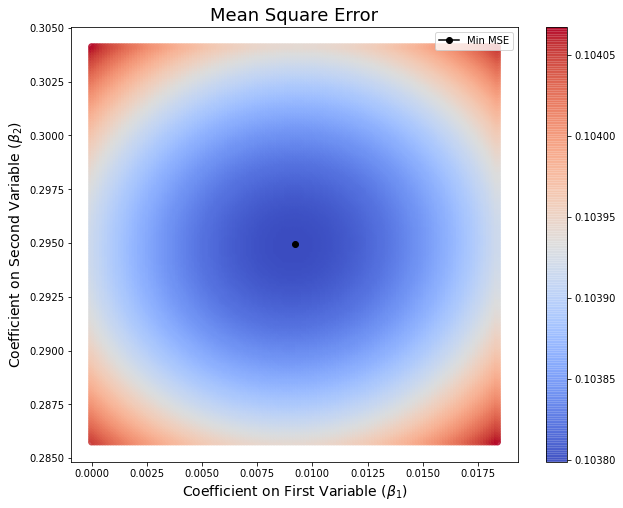

In [28]:
_plot_MSE(df_MSE, df_MSE_OLS)